In [2]:
import os
os.getcwd()

'/home/rahul/github/Ontology_Engine-KG/notebook'

In [3]:
os.chdir("..")
os.getcwd()

'/home/rahul/github/Ontology_Engine-KG'

In [4]:
from __future__ import annotations

from typing import TypedDict

from langgraph.graph import END, START, StateGraph

from db.neo4j_client import GraphRepository
from services.extraction_service import ExtractionService
from services.insight_service import InsightService
from services.reasoning_service import ReasoningService
from utils.logging import get_logger

logger = get_logger(__name__)


class WorkflowState(TypedDict, total=False):
    question: str
    normalized: dict
    entities: list
    relationships: list
    retrieved_docs: list
    drivers: list[str]
    confidence: float
    insight: dict
    logs: list[str]


class FinancialWorkflow:
    def __init__(
        self,
        extraction_service: ExtractionService,
        reasoning_service: ReasoningService,
        insight_service: InsightService,
        graph_repo: GraphRepository,
    ) -> None:
        self.extraction_service = extraction_service
        self.reasoning_service = reasoning_service
        self.insight_service = insight_service
        self.graph_repo = graph_repo
        self.graph = self._build_graph()

    def _build_graph(self):
        builder = StateGraph(WorkflowState)
        builder.add_node("IngestionAgent", self._ingestion_agent)
        builder.add_node("ExtractionAgent", self._extraction_agent)
        builder.add_node("EntityLinkingAgent", self._entity_linking_agent)
        builder.add_node("GraphUpdateAgent", self._graph_update_agent)
        builder.add_node("ReasoningAgent", self._reasoning_agent)
        builder.add_node("InsightAgent", self._insight_agent)

        builder.add_edge(START, "IngestionAgent")
        builder.add_edge("IngestionAgent", "ExtractionAgent")
        builder.add_edge("ExtractionAgent", "EntityLinkingAgent")
        builder.add_edge("EntityLinkingAgent", "GraphUpdateAgent")
        builder.add_edge("GraphUpdateAgent", "ReasoningAgent")
        builder.add_edge("ReasoningAgent", "InsightAgent")
        builder.add_edge("InsightAgent", END)

        return builder.compile()

    def run(self, state: WorkflowState) -> WorkflowState:
        return self.graph.invoke(state)

    def _append_log(self, state: WorkflowState, message: str) -> None:
        state.setdefault("logs", []).append(message)
        logger.info(message)

    def _ingestion_agent(self, state: WorkflowState) -> WorkflowState:
        self._append_log(state, "IngestionAgent: Accepted normalized query context")
        return state

    def _extraction_agent(self, state: WorkflowState) -> WorkflowState:
        entities, relationships = self.extraction_service.extract(state["question"])
        state["entities"] = entities
        state["relationships"] = relationships
        self._append_log(
            state,
            f"ExtractionAgent: extracted {len(entities)} entities and {len(relationships)} relationships",
        )
        return state

    def _entity_linking_agent(self, state: WorkflowState) -> WorkflowState:
        self._append_log(state, "EntityLinkingAgent: deduplicated entities by canonical id")
        return state

    def _graph_update_agent(self, state: WorkflowState) -> WorkflowState:
        self.graph_repo.upsert_entities(state.get("entities", []))
        self.graph_repo.add_relationships(state.get("relationships", []))
        self._append_log(state, "GraphUpdateAgent: graph repository updated")
        return state

    def _reasoning_agent(self, state: WorkflowState) -> WorkflowState:
        drivers = self.reasoning_service.build_drivers(
            entities=state.get("entities", []),
            relationships=state.get("relationships", []),
            retrieved_docs=state.get("retrieved_docs", []),
        )
        confidence = self.reasoning_service.confidence_score(
            relationships=state.get("relationships", []),
            retrieved_docs=state.get("retrieved_docs", []),
        )
        state["drivers"] = drivers
        state["confidence"] = confidence
        self._append_log(state, "ReasoningAgent: built driver chain and confidence")
        return state

    def _insight_agent(self, state: WorkflowState) -> WorkflowState:
        insight = self.insight_service.synthesize(
            question=state["question"],
            drivers=state.get("drivers", []),
            confidence=state.get("confidence", 0.4),
        )
        state["insight"] = insight.model_dump()
        self._append_log(state, "InsightAgent: final insight generated")
        return state


In [5]:
from db.postgres_client import InsightRepository
def get_insight_repository() -> InsightRepository:
    repository = InsightRepository()
    repository.initialize()
    return repository


def get_extraction_service() -> ExtractionService:
    return ExtractionService()


def get_reasoning_service() -> ReasoningService:
    return ReasoningService()


def get_insight_service() -> InsightService:
    return InsightService()

def get_graph_repository() -> GraphRepository:
    return GraphRepository()

In [8]:
graph = FinancialWorkflow(
    extraction_service=get_extraction_service(),
    reasoning_service=get_reasoning_service(),
    insight_service=get_insight_service(),
    graph_repo=get_graph_repository(),
)

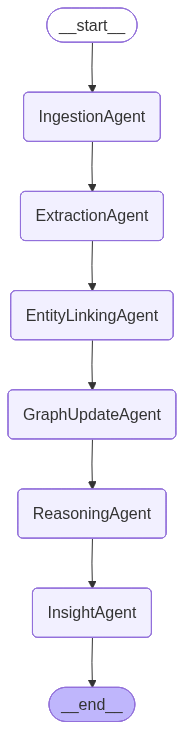

In [11]:
from IPython.display import Image, display

display(Image(graph.graph.get_graph().draw_mermaid_png()))